In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [104]:
def read_vector3_file(file_path):
    vectors = []
    with open(file_path, 'r') as file:
        for line in file:
            x, y, z = map(float, line.strip().split(','))
            vectors.append([x, y, z])
    return np.array(vectors)

import matplotlib.cm as cm
def plot_3d_scatter(vectors):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Calculate the distance from the origin
    distances = np.linalg.norm(vectors, axis=1)
    
    # Normalize distances to the range [0, 1] for color mapping
    norm = plt.Normalize(distances.min(), distances.max())
    colors = cm.viridis(norm(distances))
    
    # Plot scatter with colors based on distance
    ax.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2], c=colors, marker='o')
    
    ax.set_xlabel('X Error')
    ax.set_ylabel('Y Error')
    ax.set_zlabel('Z Error')
    
    plt.show()

In [105]:
file_path = 'errors.txt'
vectors = read_vector3_file(file_path) * 1000
vectors

array([[-2.331883e-01,  3.576279e-04, -4.842877e-04],
       [-9.442717e-01,  5.153418e-01,  1.006581e+00],
       [-1.030155e+00,  1.437187e+00,  9.253547e-01],
       [-1.233324e+00,  1.205802e+00,  9.251013e-01],
       [-1.240395e+00,  8.864403e-01,  7.690042e-01],
       [-1.639612e+00,  3.446341e-01,  9.760335e-01],
       [-1.700923e+00,  3.128052e-01,  9.731352e-01],
       [-1.700923e+00,  3.128052e-01,  9.731352e-01],
       [-1.763135e+00,  5.564690e-01,  6.944239e-01],
       [-1.523122e+00,  2.394915e-01,  1.150697e+00],
       [-1.392290e+00,  5.824566e-01,  1.219600e+00],
       [-1.392290e+00,  5.824566e-01,  1.219600e+00],
       [-9.598732e-01, -1.223683e+00, -7.332861e-01],
       [ 2.168417e-01, -8.041859e-01, -1.636833e+00],
       [ 1.204967e+00, -8.292198e-01, -1.333833e+00],
       [ 1.204967e+00, -8.292198e-01, -1.333833e+00],
       [ 1.190171e+00, -7.045269e-01, -1.355365e+00],
       [ 1.031931e+00, -8.686781e-01, -1.398981e+00],
       [ 8.578561e-01, -3.75

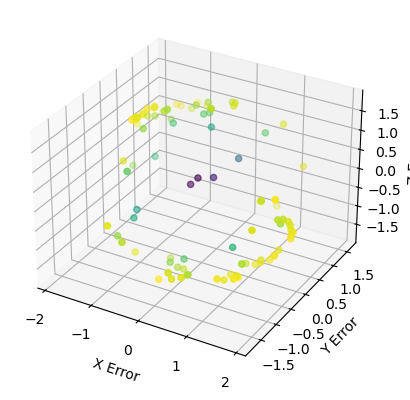

In [106]:
plot_3d_scatter(vectors)

In [32]:
absolute_values = np.abs(vectors)

array([[2.331883e-01, 3.576279e-04, 4.842877e-04],
       [9.442717e-01, 5.153418e-01, 1.006581e+00],
       [1.030155e+00, 1.437187e+00, 9.253547e-01],
       [1.233324e+00, 1.205802e+00, 9.251013e-01],
       [1.240395e+00, 8.864403e-01, 7.690042e-01],
       [1.639612e+00, 3.446341e-01, 9.760335e-01],
       [1.700923e+00, 3.128052e-01, 9.731352e-01],
       [1.700923e+00, 3.128052e-01, 9.731352e-01],
       [1.763135e+00, 5.564690e-01, 6.944239e-01],
       [1.523122e+00, 2.394915e-01, 1.150697e+00],
       [1.392290e+00, 5.824566e-01, 1.219600e+00],
       [1.392290e+00, 5.824566e-01, 1.219600e+00],
       [9.598732e-01, 1.223683e+00, 7.332861e-01],
       [2.168417e-01, 8.041859e-01, 1.636833e+00],
       [1.204967e+00, 8.292198e-01, 1.333833e+00],
       [1.204967e+00, 8.292198e-01, 1.333833e+00],
       [1.190171e+00, 7.045269e-01, 1.355365e+00],
       [1.031931e+00, 8.686781e-01, 1.398981e+00],
       [8.578561e-01, 3.750324e-01, 1.701735e+00],
       [1.093514e+00, 1.184940e

In [59]:
import seaborn as sns

def plot_absolute_value_distribution(absolute_values):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Plot absolute value histogram in X
    ax[0].hist(absolute_values[:, 0], bins=10, color='#f38181', alpha=0.7, edgecolor='white', linewidth=2, density=True)
    ax[0].set_title('Absolute Value Distribution in X (mm)')
    ax[0].set_xlabel('Absolute Value (mm)')
    ax[0].set_ylabel('Frequency')
    ax[0].set_xlim(0, max(absolute_values[:, 0]))
    sns.kdeplot(absolute_values[:, 0], ax=ax[0], color='r', linewidth=2)

    # Plot absolute value histogram in Y
    ax[1].hist(absolute_values[:, 1], bins=10, color='#71c9ce', alpha=0.7, edgecolor='white', linewidth=2, density=True)
    ax[1].set_title('Absolute Value Distribution in Y (mm)')
    ax[1].set_xlabel('Absolute Value (mm)')
    ax[1].set_ylabel('Frequency')
    ax[1].set_xlim(0, max(absolute_values[:, 1]))
    sns.kdeplot(absolute_values[:, 1], ax=ax[1], color='#3d84a8', linewidth=2)


    # Plot absolute value histogram in Z
    ax[2].hist(absolute_values[:, 2], bins=10, color='#fce38a', alpha=0.7, edgecolor='white', linewidth=2, density=True)
    ax[2].set_title('Absolute Value Distribution in Z (mm)')
    ax[2].set_xlabel('Absolute Value (mm)')
    ax[2].set_ylabel('Frequency')
    ax[2].set_xlim(0, max(absolute_values[:, 2]))
    sns.kdeplot(absolute_values[:, 2], ax=ax[2], color='#f08a5d', linewidth=2)
    
    # remove frame
    for i in range(3):
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['bottom'].set_visible(False)
        ax[i].spines['left'].set_visible(False)
        ax[i].tick_params(left = False, bottom = False)

    plt.tight_layout()
    plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


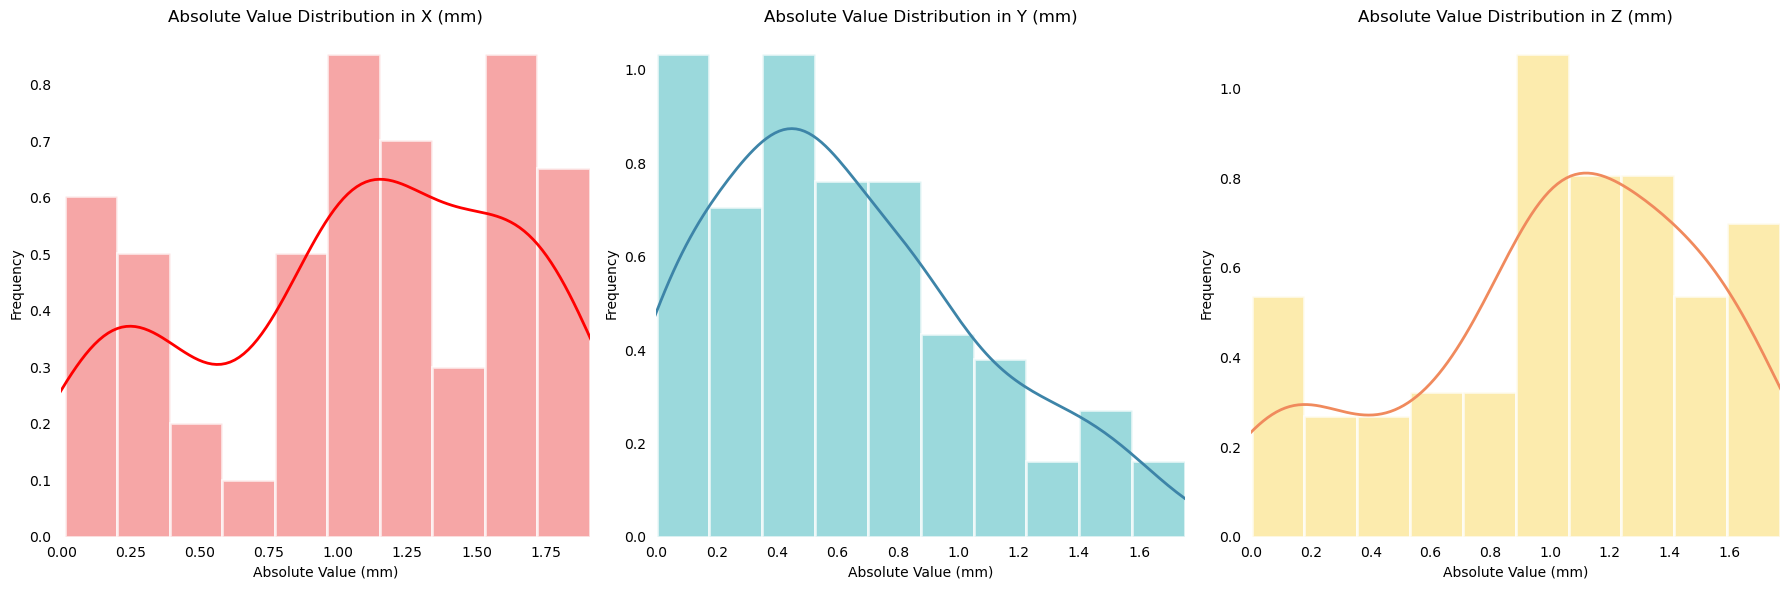

In [60]:
plot_absolute_value_distribution(absolute_values)